# PPO from scratch — CartPole

We build PPO with explicit, inspectable components:
- **PolicyNetwork** (actor): maps state → action probabilities
- **ValueNetwork** (critic): maps state → V(s)
- **GAE**: generalised advantage estimation
- **PPO objective**: clipped surrogate loss

No Stable Baselines, no abstractions. Every step is visible.

## 0. Installs

In [2]:
# !pip install gymnasium torch matplotlib

## 1. Imports

In [3]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
from collections import deque

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 2. The Policy Network (Actor)

Maps a state s → probability distribution over actions.

For CartPole: state is 4D (cart position, cart velocity, pole angle, pole angular velocity).
Actions are discrete: push left (0) or push right (1).

The output layer uses **softmax** so we get a valid probability distribution.
We then sample from this distribution — this is what makes it a *stochastic* policy.

In [5]:
class PolicyNetwork(nn.Module):
    """
    The ACTOR: π_θ(a | s)
    
    Input:  state s  (shape: [batch, state_dim])
    Output: action probabilities  (shape: [batch, n_actions])
    """
    def __init__(self, state_dim: int, n_actions: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, n_actions),
        )
    
    def forward(self, state: torch.Tensor) -> Categorical:
        """Returns a Categorical distribution over actions."""
        logits = self.net(state)          # raw unnormalised scores
        return Categorical(logits=logits) # wraps in softmax internally
    
    def get_action(self, state: torch.Tensor):
        """Sample an action and return (action, log_prob)."""
        dist = self.forward(state)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob
    
    def evaluate(self, state: torch.Tensor, action: torch.Tensor):
        """
        Used during the PPO update:
        given (state, action) from OLD policy,
        return log_prob and entropy under CURRENT policy.
        """
        dist = self.forward(state)
        log_prob = dist.log_prob(action)
        entropy  = dist.entropy()         # used to encourage exploration
        return log_prob, entropy


# Quick sanity check
env_test = gym.make("CartPole-v1")
assert env_test is not None

obs_space = env_test.observation_space
act_space = env_test.action_space
assert obs_space is not None
obs_shape = getattr(obs_space, "shape", None)
assert obs_shape is not None and len(obs_shape) > 0

assert act_space is not None
n_actions = getattr(act_space, "n", None)
assert n_actions is not None

STATE_DIM = int(obs_shape[0])  # 4
N_ACTIONS = int(n_actions)  # 2
env_test.close()

policy = PolicyNetwork(STATE_DIM, N_ACTIONS).to(DEVICE)
dummy_state = torch.zeros(1, STATE_DIM).to(DEVICE)

action, lp = policy.get_action(dummy_state)
print(f"\nPolicy architecture:\n{policy}")

print(f"State dim: {STATE_DIM}, Action dim: {N_ACTIONS}")
print(f"Sample action: {action.item()}, log_prob: {lp.item():.3f}")



Policy architecture:
PolicyNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
State dim: 4, Action dim: 2
Sample action: 0, log_prob: -0.605


## 3. The Value Network (Critic)

Maps a state s → scalar V(s): the expected future discounted return.

The critic is NOT used to select actions — it's only used to compute **advantages**:

```
A(s, a) = Q(s, a) - V(s)
         ≈ (reward + γ·V(s') - V(s))   ← TD residual
```

A positive advantage means the action was better than average → increase its probability.
A negative advantage means it was worse than average → decrease its probability.

In [6]:
class ValueNetwork(nn.Module):
    """
    The CRITIC: V_φ(s)
    
    Input:  state s  (shape: [batch, state_dim])
    Output: scalar value estimate  (shape: [batch, 1])
    """
    def __init__(self, state_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),     # single scalar output
        )
    
    def forward(self, state: torch.Tensor) -> torch.Tensor:
        return self.net(state).squeeze(-1)  # shape: [batch]


value_net = ValueNetwork(STATE_DIM).to(DEVICE)
v = value_net(dummy_state)
print(f"V(s) for zero state: {v.item():.4f}")
print(f"\nValue network architecture:\n{value_net}")

V(s) for zero state: 0.0349

Value network architecture:
ValueNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 4. Rollout Buffer

PPO is **on-policy**: we collect a batch of experience under the current policy,
run several gradient update epochs on it, then throw it away and repeat.

The buffer stores:
- `states` — what the agent observed
- `actions` — what it did
- `log_probs_old` — log π_old(a|s) — needed for the importance ratio r_t
- `rewards` / `dones` — to compute returns
- `values` — V(s) at each step — for GAE

In [7]:
class RolloutBuffer:
    """Stores one batch of on-policy experience."""
    
    def __init__(self):
        self.states      = []
        self.actions     = []
        self.log_probs   = []  # log π_old(a|s) at collection time
        self.rewards     = []
        self.dones       = []
        self.values      = []  # V(s) at collection time
    
    def store(self, state, action, log_prob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)
    
    def clear(self):
        self.__init__()
    
    def to_tensors(self):
        return (
            torch.FloatTensor(np.array(self.states)).to(DEVICE),
            torch.LongTensor(self.actions).to(DEVICE),
            torch.FloatTensor(self.log_probs).to(DEVICE),
            self.rewards,
            self.dones,
            torch.FloatTensor(self.values).to(DEVICE),
        )

print("RolloutBuffer defined.")

RolloutBuffer defined.


## 5. Generalised Advantage Estimation (GAE)

GAE computes advantages as an exponentially-weighted sum of TD residuals:

```
δ_t    = r_t + γ·V(s_{t+1}) - V(s_t)      ← TD residual (1-step advantage)
A_t^GAE = δ_t + (γλ)·δ_{t+1} + (γλ)²·δ_{t+2} + ...
```

**λ=0**: pure TD(0) — low variance, high bias (only looks 1 step ahead)
**λ=1**: Monte Carlo returns — unbiased but high variance
**λ=0.95**: the standard PPO setting — balances both

We compute this backwards through the trajectory (more numerically stable).

In [8]:
def compute_gae(
    rewards: list,
    dones: list,
    values: torch.Tensor,
    last_value: float,
    gamma: float = 0.99,
    lam: float = 0.95,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Returns:
      advantages  (shape: [T])  — used in the policy loss
      returns     (shape: [T])  — used as targets for the value network
    """
    T = len(rewards)
    advantages = torch.zeros(T).to(DEVICE)
    
    gae = 0.0
    for t in reversed(range(T)):
        # Bootstrap from last_value at the end of the rollout
        next_value = last_value if t == T - 1 else values[t + 1].item()
        next_non_terminal = 1.0 - float(dones[t])
        
        # TD residual: how much better/worse was this step than V predicted?
        delta = rewards[t] + gamma * next_value * next_non_terminal - values[t].item()
        
        # Accumulate discounted sum of deltas (backwards)
        gae = delta + gamma * lam * next_non_terminal * gae
        advantages[t] = gae
    
    # Returns = advantages + values  (targets for the critic)
    returns = advantages + values
    
    # Normalise advantages: zero mean, unit std
    # This stabilises training significantly
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    
    return advantages, returns

print("GAE function defined.")

GAE function defined.


## 6. PPO Update Step

This is the heart of PPO. Given a collected batch, we run K epochs of gradient updates.

**Policy loss (clipped surrogate)**:
```
r_t(θ) = π_θ(a|s) / π_θ_old(a|s)     ← importance ratio
         = exp(log_prob_new - log_prob_old)   ← numerically stable form

L_CLIP = E[ min( r_t · A_t,  clip(r_t, 1-ε, 1+ε) · A_t ) ]
```

**Value loss**: MSE between V_φ(s) and the GAE returns.

**Entropy bonus**: encourages exploration by penalising confident distributions.

In [9]:
def ppo_update(
    policy:        PolicyNetwork,
    value_net:     ValueNetwork,
    optimizer:     optim.Optimizer,
    states:        torch.Tensor,
    actions:       torch.Tensor,
    log_probs_old: torch.Tensor,
    advantages:    torch.Tensor,
    returns:       torch.Tensor,
    # ---- PPO hyperparameters ----
    clip_eps:      float = 0.2,   # ε in the clip objective
    n_epochs:      int   = 10,    # how many gradient steps per batch
    batch_size:    int   = 64,
    vf_coef:       float = 0.5,   # weight of value loss
    ent_coef:      float = 0.01,  # weight of entropy bonus
) -> dict:
    """Run K epochs of PPO updates on the collected rollout."""
    
    T = states.shape[0]
    metrics = {"policy_loss": [], "value_loss": [], "entropy": [], "clip_frac": []}
    
    for _ in range(n_epochs):
        # Shuffle indices for mini-batching
        indices = torch.randperm(T)
        
        for start in range(0, T, batch_size):
            mb_idx = indices[start : start + batch_size]
            
            mb_states    = states[mb_idx]
            mb_actions   = actions[mb_idx]
            mb_log_old   = log_probs_old[mb_idx]
            mb_adv       = advantages[mb_idx]
            mb_returns   = returns[mb_idx]
            
            # --- Policy loss ---
            log_probs_new, entropy = policy.evaluate(mb_states, mb_actions)
            
            # Importance ratio: how much has the policy changed?
            ratio = torch.exp(log_probs_new - mb_log_old)  # r_t(θ)
            
            # Unclipped and clipped objectives
            surr1 = ratio * mb_adv
            surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * mb_adv
            
            policy_loss = -torch.min(surr1, surr2).mean()  # negative because we ascend
            
            # --- Value loss ---
            values_pred = value_net(mb_states)
            value_loss  = nn.functional.mse_loss(values_pred, mb_returns)
            
            # --- Entropy bonus (negative because we want to maximise entropy) ---
            entropy_loss = -entropy.mean()
            
            # --- Combined loss ---
            loss = policy_loss + vf_coef * value_loss + ent_coef * entropy_loss
            
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(  # prevent exploding gradients
                list(policy.parameters()) + list(value_net.parameters()), 
                max_norm=0.5
            )
            optimizer.step()
            
            # Track what fraction of ratios got clipped (diagnostic)
            clip_frac = ((ratio - 1.0).abs() > clip_eps).float().mean().item()
            
            metrics["policy_loss"].append(policy_loss.item())
            metrics["value_loss"].append(value_loss.item())
            metrics["entropy"].append(-entropy_loss.item())
            metrics["clip_frac"].append(clip_frac)
    
    return {k: np.mean(v) for k, v in metrics.items()}

print("PPO update function defined.")

PPO update function defined.


## 7. Training Loop

The PPO training cycle:

```
repeat:
  1. Collect N steps in the environment using CURRENT policy
  2. Compute GAE advantages over the rollout
  3. Run K epochs of mini-batch gradient updates
  4. Clear the buffer, go back to 1
```

Note: we share a single Adam optimizer across both networks.

In [10]:
class CartPoleSlapWrapper(gym.Wrapper):
    """Adds a small persistent disturbance and occasional random pole slaps."""

    def __init__(
        self,
        env,
        force_amp=0.02,
        force_freq=0.35,
        slap_prob=0.04,
        slap_strength=0.22,
        slap_vel=0.30,
        state_delay=2,
    ):
        super().__init__(env)
        self.force_amp = force_amp
        self.force_freq = force_freq
        self.slap_prob = slap_prob
        self.slap_strength = slap_strength
        self.slap_vel = slap_vel
        self.state_delay = max(0, int(state_delay))
        self._obs_history: deque = deque(maxlen=self.state_delay + 1)
        self._t: float = 0.0
        self.last_force: float = 0.0
        self.last_slap: float = 0.0
        self.tip_force: float = 0.0
        self.tip_force_dir: float = 1.0

    def _disturb(self, obs):
        obs_arr = np.asarray(obs, dtype=np.float32).copy()
        self._t = float(self._t) + 1.0

        # External force acting on the pole tip. This is the thing we want to visualize.
        forcing = float(self.force_amp * np.sin(self.force_freq * self._t))
        self.tip_force = forcing
        self.tip_force_dir = 1.0 if forcing >= 0 else -1.0
        self.last_force = forcing
        self.last_slap = 0.0

        # Apply the disturbance as an angular kick so the policy must correct it.
        obs_arr[2] = float(obs_arr[2]) + 0.75 * forcing
        obs_arr[3] = float(obs_arr[3]) + 0.30 * forcing

        # Sudden slap: extra impulse at the pole tip, again represented as a horizontal force.
        if np.random.rand() < self.slap_prob:
            slap = float(np.random.uniform(-self.slap_strength, self.slap_strength))
            obs_arr[2] = float(obs_arr[2]) + 0.85 * slap
            obs_arr[3] = float(obs_arr[3]) + 0.35 * slap
            self.tip_force = float(self.tip_force) + slap
            self.tip_force_dir = 1.0 if self.tip_force >= 0 else -1.0
            self.last_slap = slap
        return obs_arr

    def _apply_state_delay(self, obs):
        obs = np.asarray(obs, dtype=np.float32).copy()
        self._obs_history.append(obs)
        if len(self._obs_history) <= self.state_delay:
            return obs.copy()
        return self._obs_history[0].copy()

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        obs = self._disturb(obs)
        self._obs_history.clear()
        self._obs_history.append(obs.copy())
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        obs = self._disturb(obs)
        delayed_obs = self._apply_state_delay(obs)
        return delayed_obs, reward, terminated, truncated, info


# ── Hyperparameters ──────────────────────────────────────────────────────────
ROLLOUT_STEPS  = 2048    # steps to collect per update
N_EPOCHS       = 10      # PPO epochs per rollout
BATCH_SIZE     = 64      # mini-batch size within each epoch
GAMMA          = 0.99    # discount factor
GAE_LAMBDA     = 0.95    # GAE λ
CLIP_EPS       = 0.2     # PPO clip range ε
LR             = 3e-4    # learning rate
VF_COEF        = 0.5     # value loss coefficient
ENT_COEF       = 0.01    # entropy bonus coefficient
TOTAL_STEPS    = 30_000  # short demo run so you can watch early learning happen

# ── Networks & Optimizer ─────────────────────────────────────────────────────
policy    = PolicyNetwork(STATE_DIM, N_ACTIONS).to(DEVICE)
value_net = ValueNetwork(STATE_DIM).to(DEVICE)

# Single optimizer across both networks (standard PPO practice)
optimizer = optim.Adam(
    list(policy.parameters()) + list(value_net.parameters()),
    lr=LR
)

# ── Environment & Buffer ─────────────────────────────────────────────────────
env    = CartPoleSlapWrapper(gym.make("CartPole-v1"), state_delay=2)
buffer = RolloutBuffer()

# ── Logging ──────────────────────────────────────────────────────────────────
episode_rewards   = []
ep_reward_history = []    # one entry per episode
update_metrics    = []
rolling_avg       = deque(maxlen=50)

state, _ = env.reset()
ep_reward: float = 0.0
total_steps: int = 0
update_count: int = 0

print(f"Training PPO on CartPole-v1 with delayed observations and random pole disturbances")
print(f"Rollout steps: {ROLLOUT_STEPS} | Epochs/update: {N_EPOCHS} | Clip ε: {CLIP_EPS} | Obs delay: 2")
print("-" * 60)

while total_steps < TOTAL_STEPS:
    # ── Phase 1: Collect rollout ──────────────────────────────────────────
    for _ in range(ROLLOUT_STEPS):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            action, log_prob = policy.get_action(state_t)
            value = value_net(state_t)

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        buffer.store(
            state=state,
            action=action.item(),
            log_prob=log_prob.item(),
            reward=reward,
            done=done,
            value=value.item(),
        )

        ep_reward = float(ep_reward) + float(reward)
        total_steps = int(total_steps) + 1
        state = next_state

        if done:
            ep_reward_history.append(ep_reward)
            rolling_avg.append(ep_reward)
            ep_reward = 0.0
            state, _ = env.reset()

    # ── Phase 2: Compute advantages ───────────────────────────────────────
    states_t, actions_t, log_probs_t, rewards, dones, values_t = buffer.to_tensors()

    with torch.no_grad():
        last_state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        last_value = value_net(last_state_t).item()

    advantages, returns = compute_gae(
        rewards, dones, values_t, last_value, GAMMA, GAE_LAMBDA
    )

    # ── Phase 3: PPO update ───────────────────────────────────────────────
    metrics = ppo_update(
        policy, value_net, optimizer,
        states_t, actions_t, log_probs_t,
        advantages, returns,
        clip_eps=CLIP_EPS, n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
        vf_coef=VF_COEF, ent_coef=ENT_COEF,
    )
    update_metrics.append(metrics)
    update_count += 1

    # ── Phase 4: Clear buffer ─────────────────────────────────────────────
    buffer.clear()

    # Logging every 5 updates
    if update_count % 5 == 0:
        avg_reward = np.mean(rolling_avg) if rolling_avg else 0
        print(
            f"Step {total_steps:>7,} | "
            f"Avg reward (50ep): {avg_reward:>6.1f} | "
            f"π loss: {metrics['policy_loss']:>6.4f} | "
            f"V loss: {metrics['value_loss']:>6.4f} | "
            f"Entropy: {metrics['entropy']:.3f} | "
            f"Clip frac: {metrics['clip_frac']:.3f}"
        )

    # Stop once we hit the short demo budget
    if total_steps >= TOTAL_STEPS:
        break

print("\nTraining complete.")

# close environment after training
env.close()

Training PPO on CartPole-v1 with delayed observations and random pole disturbances
Rollout steps: 2048 | Epochs/update: 10 | Clip ε: 0.2 | Obs delay: 2
------------------------------------------------------------
Step  10,240 | Avg reward (50ep):   68.8 | π loss: -0.0080 | V loss: 80.0574 | Entropy: 0.595 | Clip frac: 0.027
Step  20,480 | Avg reward (50ep):  186.7 | π loss: -0.0097 | V loss: 40.0359 | Entropy: 0.470 | Clip frac: 0.099
Step  30,720 | Avg reward (50ep):  314.8 | π loss: 0.0026 | V loss: 94.6243 | Entropy: 0.416 | Clip frac: 0.047

Training complete.


## 8. Training Diagnostics

What to look for:
- **Episode reward** should climb toward ~500 (CartPole max)
- **Policy loss** noisy but generally near zero
- **Value loss** should decrease as the critic learns V(s)
- **Entropy** should gradually decrease as the policy becomes more confident
- **Clip fraction** should stay below ~0.2 — if it's high, the policy is changing too fast

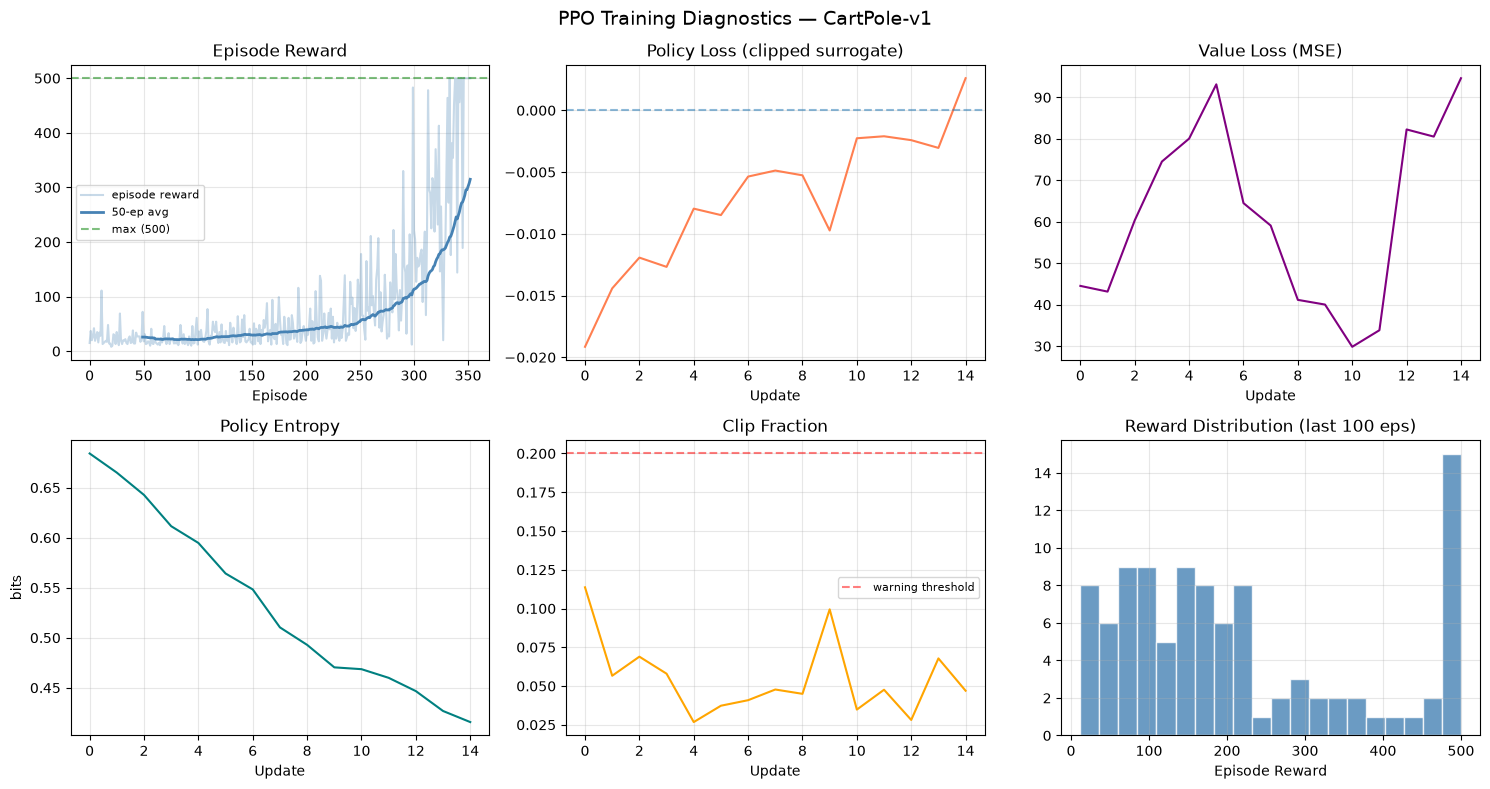

Final 50-episode avg reward: 314.8


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("PPO Training Diagnostics — CartPole-v1", fontsize=14)

# Episode rewards
ax = axes[0, 0]
ax.plot(ep_reward_history, alpha=0.3, color="steelblue", label="episode reward")
window = 50
if len(ep_reward_history) >= window:
    smoothed = np.convolve(ep_reward_history, np.ones(window)/window, mode="valid")
    ax.plot(range(window-1, len(ep_reward_history)), smoothed, color="steelblue", linewidth=2, label=f"{window}-ep avg")
ax.axhline(500, linestyle="--", color="green", alpha=0.5, label="max (500)")
ax.set_title("Episode Reward")
ax.set_xlabel("Episode")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Extract per-update metrics
policy_losses = [m["policy_loss"] for m in update_metrics]
value_losses  = [m["value_loss"]  for m in update_metrics]
entropies     = [m["entropy"]     for m in update_metrics]
clip_fracs    = [m["clip_frac"]   for m in update_metrics]

# Policy loss
ax = axes[0, 1]
ax.plot(policy_losses, color="coral")
ax.set_title("Policy Loss (clipped surrogate)")
ax.set_xlabel("Update")
ax.axhline(0, linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)

# Value loss
ax = axes[0, 2]
ax.plot(value_losses, color="purple")
ax.set_title("Value Loss (MSE)")
ax.set_xlabel("Update")
ax.grid(True, alpha=0.3)

# Entropy
ax = axes[1, 0]
ax.plot(entropies, color="teal")
ax.set_title("Policy Entropy")
ax.set_xlabel("Update")
ax.set_ylabel("bits")
ax.grid(True, alpha=0.3)

# Clip fraction
ax = axes[1, 1]
ax.plot(clip_fracs, color="orange")
ax.axhline(0.2, linestyle="--", color="red", alpha=0.5, label="warning threshold")
ax.set_title("Clip Fraction")
ax.set_xlabel("Update")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Reward distribution (final 100 episodes)
ax = axes[1, 2]
final_rewards = ep_reward_history[-100:] if len(ep_reward_history) >= 100 else ep_reward_history
ax.hist(final_rewards, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
ax.set_title(f"Reward Distribution (last {len(final_rewards)} eps)")
ax.set_xlabel("Episode Reward")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ppo_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Final 50-episode avg reward: {np.mean(ep_reward_history[-50:]):.1f}")

## 9. Inspect the learned policy

Examine what the policy has learned: action probabilities as a function of pole angle.

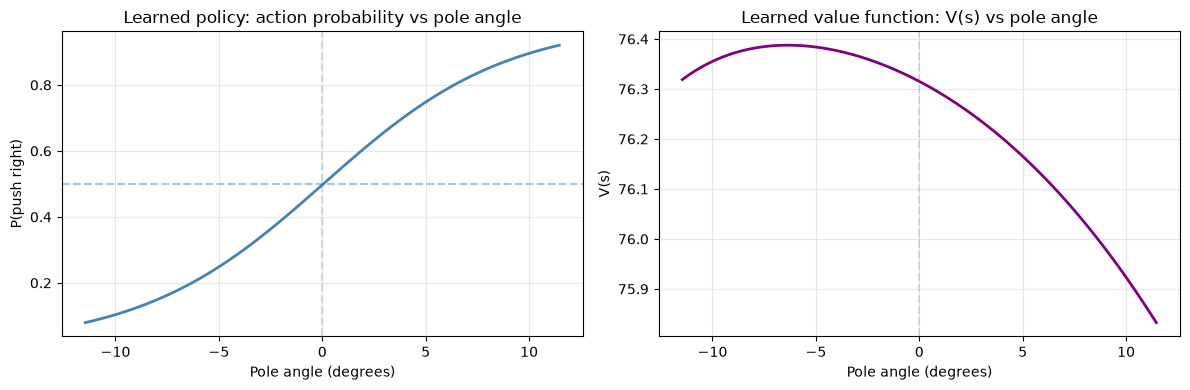

In [12]:
policy.eval()
value_net.eval()

# Sweep pole angle from -0.2 to 0.2 radians (index 2 in the state vector)
# Keep all other state dimensions at zero
angles = np.linspace(-0.2, 0.2, 100)
probs_right = []
values_at_angle = []

with torch.no_grad():
    for angle in angles:
        # state: [cart_pos, cart_vel, pole_angle, pole_angular_vel]
        state_vec = torch.FloatTensor([[0, 0, angle, 0]]).to(DEVICE)
        dist  = policy(state_vec)
        probs = dist.probs[0].cpu().numpy()
        value = value_net(state_vec).item()
        probs_right.append(probs[1])   # prob of pushing right
        values_at_angle.append(value)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(np.degrees(angles), probs_right, color="steelblue", linewidth=2)
ax1.axhline(0.5, linestyle="--", alpha=0.4)
ax1.axvline(0, linestyle="--", alpha=0.2)
ax1.set_xlabel("Pole angle (degrees)")
ax1.set_ylabel("P(push right)")
ax1.set_title("Learned policy: action probability vs pole angle")
ax1.grid(True, alpha=0.3)

# Expected: when pole tilts right (+angle), agent pushes right
# When pole tilts left (-angle), agent pushes left

ax2.plot(np.degrees(angles), values_at_angle, color="purple", linewidth=2)
ax2.axvline(0, linestyle="--", alpha=0.2)
ax2.set_xlabel("Pole angle (degrees)")
ax2.set_ylabel("V(s)")
ax2.set_title("Learned value function: V(s) vs pole angle")
ax2.grid(True, alpha=0.3)

# Expected: V(s) peaks near angle=0 (upright = high expected return)
# and falls off as the pole tilts further

plt.tight_layout()
plt.show()

## 10. Experiments to try

Break things deliberately to build intuition:

```python
# 1. Disable clipping — watch training destabilise
CLIP_EPS = 1.0   # effectively no clip

# 2. Single epoch — sample inefficient, slower convergence
N_EPOCHS = 1

# 3. No entropy bonus — policy collapses to deterministic too early
ENT_COEF = 0.0

# 4. λ=0 in GAE — pure TD(0), high bias, smooth but slow
GAE_LAMBDA = 0.0

# 5. λ=1 in GAE — Monte Carlo, unbiased but high variance, noisy
GAE_LAMBDA = 1.0

# 6. No advantage normalisation — comment out the normalisation in compute_gae()
#    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

# 7. Shared network — combine actor and critic into one network with two heads
#    (more parameter efficient, used in many production implementations)
```

## 11. Render a trained episode as an animation

This cell rolls out a trained policy in CartPole and saves a GIF so you can watch the agent behave after training.

It uses Gymnasium's `rgb_array` render mode, which is the easiest way to capture frames for an animation.

In [13]:
# Render a trained rollout and save a GIF
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageDraw

policy.eval()
value_net.eval()

env_render = CartPoleSlapWrapper(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    force_amp=0.08,
    force_freq=0.25,
    slap_prob=0.06,
    slap_strength=0.45,
    slap_vel=0.35,
    state_delay=2,
)
obs, _ = env_render.reset()
state = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
frames = []

for _ in range(500):
    with torch.no_grad():
        dist = policy(state)
        action = dist.probs.argmax(dim=-1)

    obs, reward, terminated, truncated, _ = env_render.step(action.item())
    frame = env_render.render()
    if frame is None:
        continue

    # Draw the instantaneous pole-tip disturbance exactly at the pole tip.
    force = float(env_render.tip_force)
    cart_pos, pole_angle = float(obs[0]), float(obs[2])
    cart_x_px = 300 + cart_pos * 80
    pole_len_px = 120
    tip_x = cart_x_px + np.sin(pole_angle) * pole_len_px
    tip_y = 175 - np.cos(pole_angle) * pole_len_px

    # Use a bigger visual scale so the force is clearly visible in the GIF.
    arrow_mag = max(abs(force) * 2600.0, 80.0)
    dx = np.sign(force) * min(arrow_mag, 140.0) if abs(force) > 1e-9 else 0.0
    end_x = tip_x + dx
    end_y = tip_y
    frame_array = np.asarray(frame)
    pil_img = Image.fromarray(frame_array).convert("RGBA")
    draw = ImageDraw.Draw(pil_img)

    # Draw a shaft that stops at the arrowhead base.
    v_x = end_x - tip_x
    v_y = end_y - tip_y
    norm = np.hypot(v_x, v_y)
    if norm > 0:
        ux = v_x / norm
        uy = v_y / norm
        px = -uy
        py = ux
        head_len = 28.0
        head_half_width = 16.0
        base_x = end_x - ux * head_len
        base_y = end_y - uy * head_len
        draw.line(
            (tip_x, tip_y, base_x, base_y),
            fill=(255, 0, 0, 255),
            width=10,
        )
        draw.polygon(
            [
                (end_x, end_y),
                (base_x + px * head_half_width, base_y + py * head_half_width),
                (base_x - px * head_half_width, base_y - py * head_half_width),
            ],
            fill=(255, 0, 0, 255),
        )

    draw.text((tip_x + 10, tip_y - 22), "tip force", fill=(255, 255, 255, 255))

    frames.append(np.array(pil_img.convert("RGB")))

    if terminated or truncated:
        obs, _ = env_render.reset()
        state = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
    else:
        state = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)

env_render.close()

print(f"Captured {len(frames)} frames for a rollout GIF")

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(frames[0])
ax.axis("off")

def update(frame_idx):
    im.set_data(frames[frame_idx])
    return [im]

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=30,
    blit=True,
)

anim.save("cartpole_trained_rollout.gif", writer=PillowWriter(fps=30))
print("Saved GIF as cartpole_trained_rollout.gif")
plt.close(fig)

# Save a force-vs-angle diagnostic locally in the project folder.
angles = []
forces = []
lagged_angles = []

# Re-run a short policy trajectory with the same disturbance model to plot the force/angle relationship.
plot_env = CartPoleSlapWrapper(
    gym.make("CartPole-v1"),
    force_amp=0.08,
    force_freq=0.25,
    slap_prob=0.06,
    slap_strength=0.45,
    state_delay=2,
)
obs, _ = plot_env.reset()
state_plot = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
obs_history = deque(maxlen=3)

for _ in range(300):
    with torch.no_grad():
        dist = policy(state_plot)
        action = dist.probs.argmax(dim=-1)
    obs, reward, terminated, truncated, _ = plot_env.step(action.item())
    obs_history.append(np.array(obs, dtype=np.float32).copy())
    if len(obs_history) > 2:
        lagged_angles.append(float(obs_history[0][2]))
    else:
        lagged_angles.append(float(obs[2]))
    angles.append(float(obs[2]))
    forces.append(float(plot_env.tip_force))
    state_plot = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
    if terminated or truncated:
        obs, _ = plot_env.reset()
        state_plot = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        obs_history.clear()

plot_env.close()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(angles, forces, s=10, alpha=0.7, color="crimson")
ax.set_xlabel("Pole angle, θ (rad)")
ax.set_ylabel("Tip force, F")
ax.set_title("External forcing vs pole angle")
ax.axhline(0.0, color="black", lw=0.8, alpha=0.5)
ax.axvline(0.0, color="black", lw=0.8, alpha=0.5)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig("forcing_vs_angle.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved force-vs-angle figure as forcing_vs_angle.png")

# Save the delayed-observation comparison so the latency is visible in a figure.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(angles, label="true angle", linewidth=1.6, alpha=0.9)
ax.plot(lagged_angles, label="delayed observation", linewidth=1.6, alpha=0.8)
ax.set_xlabel("time step")
ax.set_ylabel("pole angle (rad)")
ax.set_title("True angle vs delayed observation")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig("angle_delay_comparison.png", dpi=150, bbox_inches="tight")
plt.close(fig)

plt.close(fig)
print("Saved delayed-observation comparison as angle_delay_comparison.png")

Captured 500 frames for a rollout GIF
Saved GIF as cartpole_trained_rollout.gif
Saved force-vs-angle figure as forcing_vs_angle.png
Saved delayed-observation comparison as angle_delay_comparison.png
